In [27]:
from __future__ import annotations

import csv
import math
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from torch import nn
from torch.optim import AdamW

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_float32_matmul_precision("high")

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "LD2011_2014.txt"
RESULTS_PATH = PROJECT_ROOT / "results" / "patchtst_patch_size_results.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset exists: {DATA_PATH.exists()} ({DATA_PATH})")
print(f"Results CSV exists: {RESULTS_PATH.exists()} ({RESULTS_PATH})")


Project root: /workspace/deep_learning
Dataset exists: True (/workspace/deep_learning/dataset/LD2011_2014.txt)
Results CSV exists: True (/workspace/deep_learning/results/patchtst_patch_size_results.csv)


In [92]:
@dataclass(frozen=True)
class ExperimentConfig:
    patch_size: int = 16
    lookback: int = 96
    pred_len: int = 96
    train_ratio: float = 0.8
    batch_size: int = 32
    embed_dim: int = 128
    num_layers: int = 3
    num_heads: int = 16
    ff_dim: int = 256
    dropout: float = 0.2
    lr: float = 1e-4
    weight_decay: float = 0.01
    epochs: int = 3
    max_train_batches: int | None = 200
    max_eval_batches: int | None = 150
    seed: int = 42


CFG = ExperimentConfig()
CFG

ExperimentConfig(patch_size=16, lookback=96, pred_len=96, train_ratio=0.8, batch_size=32, embed_dim=128, num_layers=3, num_heads=16, ff_dim=256, dropout=0.2, lr=0.0001, weight_decay=0.01, epochs=3, max_train_batches=200, max_eval_batches=150, seed=42)

In [93]:
class TimeDataset(torch.utils.data.Dataset):
    def __init__(self, data: np.ndarray, seq_len: int = 96, pred_len: int = 96):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.data = data.astype(np.float32, copy=False)

    def __len__(self) -> int:
        return max(0, len(self.data) - self.seq_len - self.pred_len + 1)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.from_numpy(x), torch.from_numpy(y)


def load_raw_dataframe(data_path: Path) -> pd.DataFrame:
    df = pd.read_csv(data_path, sep=";", decimal=",", index_col=0)
    df.index = pd.to_datetime(df.index)
    return df


def split_and_normalize(df: pd.DataFrame, train_ratio: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    values = df.to_numpy(dtype=np.float64, copy=True)
    split_idx = int(len(values) * train_ratio)
    train = values[:split_idx]
    test = values[split_idx:]

    mean = train.mean(axis=0, keepdims=True)
    std = train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)

    train_norm = (train - mean) / std
    test_norm = (test - mean) / std
    return train_norm.astype(np.float32), test_norm.astype(np.float32), mean, std


In [94]:
class RevIN(nn.Module):
    def __init__(self, eps: float = 1e-5):
        super().__init__()
        self.mean = None
        self.std = None
        self.eps = eps

    def forward(self, x: torch.Tensor, mode: str = "norm") -> torch.Tensor:
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            return (x - self.mean) / self.std
        if mode == "denorm":
            return x * self.std + self.mean
        raise ValueError(f"Unknown RevIN mode: {mode}")


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 100):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class Patching(nn.Module):
    def __init__(self, patch_size: int, embed_dim: int):
        super().__init__()
        self.patch = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, lookback_len, num_channels = x.shape
        channel_independent = x.permute(0, 2, 1).reshape(batch_size * num_channels, 1, lookback_len)
        return self.patch(channel_independent).permute(0, 2, 1)


class PatchTST(nn.Module):
    def __init__(
        self,
        lookback_len: int,
        pred_len: int,
        patch_size: int,
        embed_dim: int,
        num_layers: int = 2,
        num_heads: int = 4,
        ff_dim: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.lookback_len = lookback_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.revin = RevIN()
        self.patching = Patching(patch_size, embed_dim)

        patch_count = ((lookback_len - patch_size) // patch_size) + 1
        self.pos_encoding = PositionalEncoding(embed_dim, dropout=dropout, max_len=patch_count)
        encoder_layer = nn.TransformerEncoderLayer(
            embed_dim,
            num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.head = nn.Linear(patch_count * embed_dim, pred_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, _, num_channels = x.shape
        x = self.revin(x)
        patched = self.patching(x)
        encoded = self.encoder(self.pos_encoding(patched))
        out = self.head(encoded.reshape(batch_size, num_channels, -1)).permute(0, 2, 1)
        return self.revin(out, "denorm")


In [95]:
def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def run_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    optimizer: torch.optim.Optimizer,
) -> float:
    model.train()
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    count = 0

    for x, y in tqdm(loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        count += 1

    return total_loss / max(count, 1)

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[float, float, float]:
    model.eval()
    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_points = 0

    for batch_idx, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        diff = pred - y

        total_squared_error += torch.sum(diff * diff).item()
        total_absolute_error +=  torch.sum(torch.abs(diff)).item()
        total_points += diff.numel()

    mse = total_squared_error / max(total_points, 1)
    mae = total_absolute_error / max(total_points, 1)
    rmse = math.sqrt(mse)
    return mse, mae, rmse

In [96]:
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import trange
from tqdm import tqdm

device = choose_device()
df = load_raw_dataframe(DATA_PATH)
train_data, test_data, _, _ = split_and_normalize(df, CFG.train_ratio)
train_dataset = TimeDataset(train_data, seq_len=CFG.lookback, pred_len=CFG.pred_len)
test_dataset = TimeDataset(test_data, seq_len=CFG.lookback, pred_len=CFG.pred_len)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    drop_last=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    drop_last=False,
)

model = PatchTST(
    lookback_len=CFG.lookback,
    pred_len=CFG.pred_len,
    patch_size=CFG.patch_size,
    embed_dim=CFG.embed_dim,
    num_layers=CFG.num_layers,
    num_heads=CFG.num_heads,
    ff_dim=CFG.ff_dim,
    dropout=CFG.dropout,
).to(device)
optimizer = AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

for i in range(CFG.epochs):
    train_loss = run_epoch(model, train_loader, device, optimizer)
    mse, mae, rmse = evaluate(model, test_loader, device)
    print(f"Train: {train_loss}, Test mse: {mse}, mae: {mae}")

100%|██████████| 3500/3500 [11:12<00:00,  5.20it/s]


Train: 0.14518383559371745, Test mse: 14.827762634001571, mae: 0.40799035202652784


 82%|████████▏ | 2863/3500 [09:10<02:02,  5.20it/s]


KeyboardInterrupt: 

x tensor(205.0984, grad_fn=<MeanBackward0>)
x tensor(132)


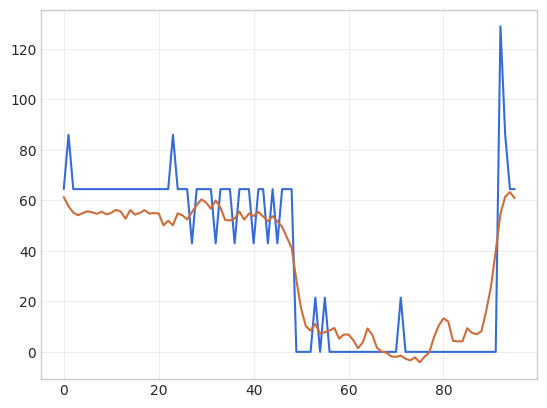

<BarContainer object of 370 artists>

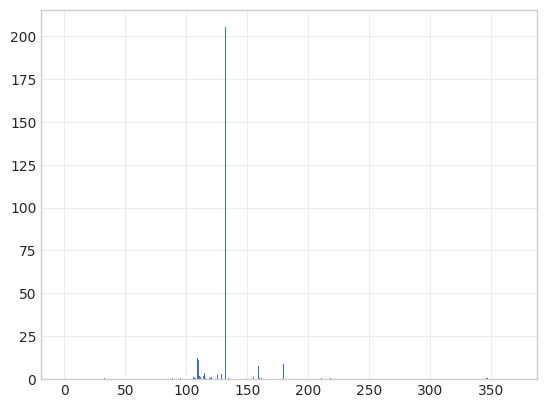

In [133]:
dataset_test = TimeDataset(test_data, seq_len=CFG.lookback, pred_len=CFG.pred_len)
var = 132

x, y = dataset_test[0]
pred = model(x.unsqueeze(0).to(device)).squeeze(0).cpu()
print("x", (pred - y)[:, var].pow(2).mean())
print("x", (pred - y).pow(2).mean(dim=0).argmax())
plt.plot(y[:, var])
plt.plot(pred[:, var].detach())
plt.show()
plt.bar(range(370), (pred - y).pow(2).mean(dim=0).detach())

In [90]:
evaluate(model, train_loader, device)

(0.11906246807044384, 0.1777437633813885, 0.3450542972786223)

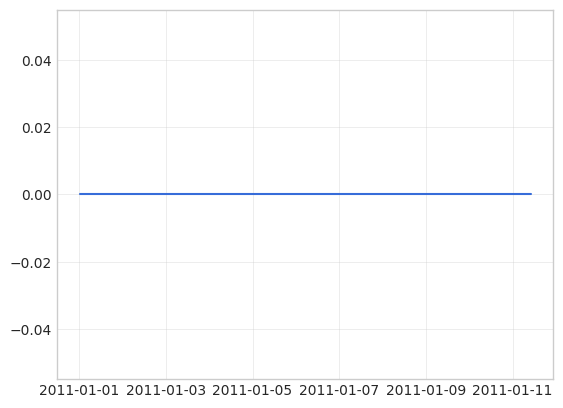

In [53]:
d = load_raw_dataframe(DATA_PATH)


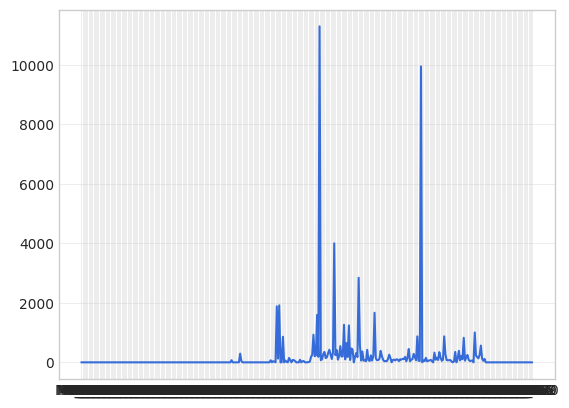

In [115]:
plt.plot(d.iloc[132])

In [117]:
d.iloc[132].std()

np.float64(1852.8426512079216)

In [129]:
_, _, mean, std = split_and_normalize(d, 0.8)

In [130]:
std[0, 132]

np.float64(0.06261428668739137)

In [141]:
d[int(len(d)*0.8):].std().iloc[132]

np.float64(3.493889808908636)